In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 53.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 62.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 86.9 MB/s eta 0:00:00:00:0100:01


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import pennylane as qml

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(q_params):
    """
    A simple quantum circuit.
    Expects q_params of shape (n_qubits, 3) where for each qubit three parameters
    are used for rotations.
    """
    # Apply parameterized rotations on each qubit.
    for i in range(n_qubits):
        qml.RY(q_params[i, 0], wires=i)
        qml.RZ(q_params[i, 1], wires=i)
        qml.RX(q_params[i, 2], wires=i)
    # A ring of CNOTs to entangle the qubits.
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    qml.CNOT(wires=[n_qubits - 1, 0])
    # Measure expectation values of PauliZ on each qubit.
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


In [5]:
class QuantumGenerator(nn.Module):
    def __init__(self, latent_dim, n_qubits, hidden_dim=128):
        """
        Args:
            latent_dim: Dimension of the noise vector.
            n_qubits: Number of qubits in the quantum circuit.
            hidden_dim: Size of the hidden layer in the post–processing network.
        """
        super(QuantumGenerator, self).__init__()
        self.latent_dim = latent_dim
        self.n_qubits = n_qubits
        
        # Map the noise vector to parameters for the quantum circuit.
        # We need n_qubits*3 parameters (three per qubit).
        self.fc_q = nn.Linear(latent_dim, n_qubits * 3)
        
        # Post–processing: combine the quantum output with the original noise.
        self.fc_post = nn.Sequential(
            nn.Linear(latent_dim + n_qubits, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 784),  # MNIST images are 28x28 = 784 pixels.
            nn.Sigmoid()  # Pixel values between 0 and 1.
        )
        
    def forward(self, z):
        batch_size = z.size(0)
        # Map the noise to quantum circuit parameters.
        q_params = self.fc_q(z)  # Shape: (batch_size, n_qubits*3)
        q_params = q_params.view(batch_size, self.n_qubits, 3)
        
        # Run the quantum circuit for each sample in the batch.
        q_out = []
        for i in range(batch_size):
            q_out.append(quantum_circuit(q_params[i]))
        # Stack into a tensor of shape (batch_size, n_qubits)
        q_out = torch.tensor(q_out, device=z.device, dtype=z.dtype)

        
        # Combine the quantum output with the original noise.
        combined = torch.cat([z, q_out], dim=1)  # Shape: (batch_size, latent_dim + n_qubits)
        img_flat = self.fc_post(combined)  # Shape: (batch_size, 784)
        # Reshape into a 28x28 image.
        img = img_flat.view(-1, 1, 28, 28)
        return img


In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # Input: (batch_size, 1, 28, 28)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),  # -> (batch, 64, 14, 14)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # -> (batch, 128, 7, 7)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()  # Output a probability.
        )
        
    def forward(self, img):
        validity = self.model(img)
        return validity


In [7]:
# Use torchvision transforms to convert images to tensors.
transform = transforms.Compose([
    transforms.ToTensor(),  # MNIST pixels are scaled between 0 and 1.
])


In [8]:
# Download and load the MNIST training dataset.
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.61MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [9]:
latent_dim = 10  # Dimension of the random noise.
generator = QuantumGenerator(latent_dim, n_qubits).to(device)
discriminator = Discriminator().to(device)

# Standard Binary Cross Entropy loss.
adversarial_loss = nn.BCELoss()

# Optimizers for generator and discriminator.
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [10]:
num_epochs = 25
for epoch in range(num_epochs):
    for i, (imgs, _) in enumerate(train_loader):
        batch_size = imgs.size(0)
        real_imgs = imgs.to(device)
        
        # Create ground-truth labels: 1 for real, 0 for fake.
        valid = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)
        
        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()
        
        # Sample noise as generator input.
        z = torch.randn(batch_size, latent_dim, device=device)
        gen_imgs = generator(z)
        
        # The generator aims to fool the discriminator:
        # We want the discriminator to output 1 for fake images.
        g_loss = adversarial_loss(discriminator(gen_imgs), valid)
        
        g_loss.backward()
        optimizer_G.step()
        
        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()
        
        # Loss for real images.
        real_loss = adversarial_loss(discriminator(real_imgs), valid)
        # Loss for fake images.
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
        # Combined loss.
        d_loss = (real_loss + fake_loss) / 2
        
        d_loss.backward()
        optimizer_D.step()
        
        # (Optional) If you want to monitor losses in specific ranges,
        # you could check their values here. In a well–trained GAN on MNIST,
        # you may see discriminator losses roughly between 0 and 1 and
        # generator losses roughly between 0 and 2.
        #
        # **Note:** Do not simply clamp the losses (e.g. using torch.clamp)
        # during training as that interferes with gradient backpropagation.
        
        if i % 100 == 0:
            print(
                f"[Epoch {epoch+1}/{num_epochs}] [Batch {i}/{len(train_loader)}] "
                f"D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}"
            )


[Epoch 1/25] [Batch 0/938] D loss: 0.6353 | G loss: 1.0548
[Epoch 1/25] [Batch 100/938] D loss: 0.0015 | G loss: 7.2460
[Epoch 1/25] [Batch 200/938] D loss: 0.0010 | G loss: 7.8284
[Epoch 1/25] [Batch 300/938] D loss: 0.0010 | G loss: 7.4814
[Epoch 1/25] [Batch 400/938] D loss: 0.0009 | G loss: 7.0708
[Epoch 1/25] [Batch 500/938] D loss: 0.0006 | G loss: 7.2872
[Epoch 1/25] [Batch 600/938] D loss: 0.0005 | G loss: 7.9473
[Epoch 1/25] [Batch 700/938] D loss: 0.0003 | G loss: 8.8632
[Epoch 1/25] [Batch 800/938] D loss: 0.0002 | G loss: 8.6128
[Epoch 1/25] [Batch 900/938] D loss: 0.0001 | G loss: 9.0766
[Epoch 2/25] [Batch 0/938] D loss: 0.0001 | G loss: 8.6949
[Epoch 2/25] [Batch 100/938] D loss: 0.0001 | G loss: 9.2131
[Epoch 2/25] [Batch 200/938] D loss: 0.0001 | G loss: 9.5574
[Epoch 2/25] [Batch 300/938] D loss: 0.0001 | G loss: 9.3547
[Epoch 2/25] [Batch 400/938] D loss: 0.0002 | G loss: 9.5250
[Epoch 2/25] [Batch 500/938] D loss: 0.0001 | G loss: 9.9555
[Epoch 2/25] [Batch 600/938]

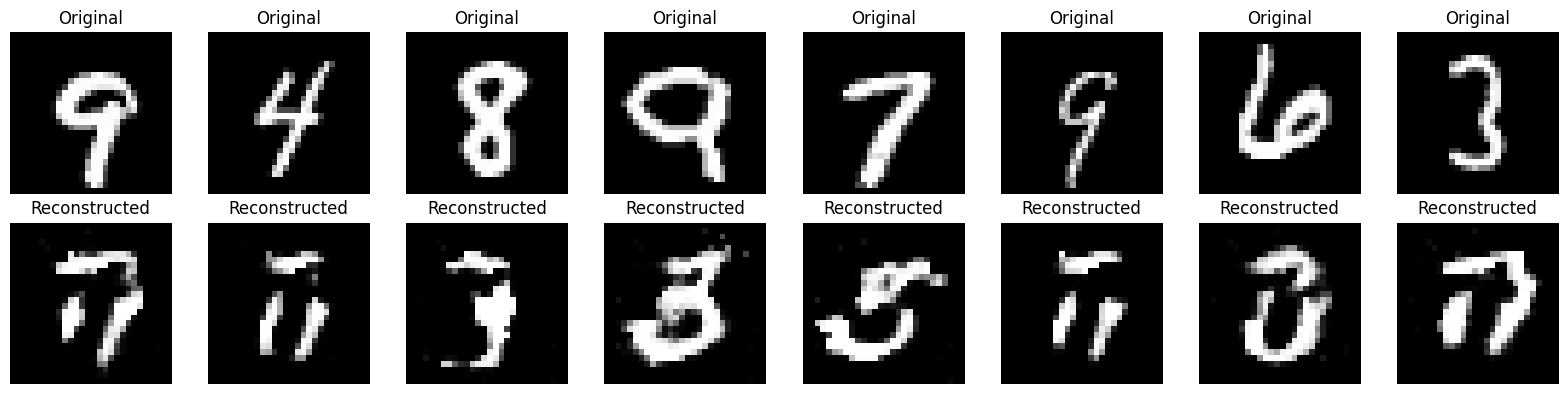

In [11]:
import matplotlib.pyplot as plt
def display_results(generator, data_loader, latent_dim, device, num_images=8):
    """
    Displays a few original MNIST images (from data_loader) alongside images generated
    by the generator.
    
    Args:
        generator: The generator model.
        data_loader: A DataLoader from which to fetch real images.
        latent_dim: Dimension of the latent noise vector.
        device: The device (cpu or cuda).
        num_images: Number of images to display.
    """
    generator.eval()  # Set generator to evaluation mode
    with torch.no_grad():
        # Fetch a single batch of real images.
        real_imgs, _ = next(iter(data_loader))
        real_imgs = real_imgs.to(device)[:num_images]
        
        # Generate a batch of images from random noise.
        z = torch.randn(num_images, latent_dim, device=device)
        gen_imgs = generator(z)
    
    # Convert the images to numpy arrays for plotting.
    real_imgs_np = real_imgs.cpu().numpy()
    gen_imgs_np = gen_imgs.cpu().numpy()
    
    # Plot the images.
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
    for i in range(num_images):
        # Original image
        axes[0, i].imshow(real_imgs_np[i, 0], cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title("Original")
        # Generated (reconstructed) image
        axes[1, i].imshow(gen_imgs_np[i, 0], cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title("Reconstructed")
    plt.tight_layout()
    plt.show()

# Display a few samples after training.
display_results(generator, train_loader, latent_dim, device)